# KBO Win Rate Analysis Part 2: Integrating Pitching and Batting Data

How much do defensive, batting, and pitching ability each contribute to win rate? (2001-2021)

In [70]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels openpyxl


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Project Statement

1. Address what defense alone couldn't explain, by integrating pitching and batting data (multiple regression)
2. Use DIPS theory to separate pitcher skill from defensive contribution
3. Pythagorean residual analysis — identify which metrics stand out for teams that over/under-performed relative to run differential
4. Scoring power vs run prevention — which drives win rate more strongly?

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

## 2. Data Loading & Preprocessing

The pitching/batting data and the existing defensive data cover different KBO regular-season periods (pitching/batting: 1982–2021, defense: 2001–2024), so the analysis was restricted to their intersection, **2001–2021**. 

In [72]:
pitch=pd.read_csv('data/kbopitchingdata.csv')
pitch=pitch.loc[pitch.year >=2001]
pitch.head()

,id,year,team,average_age,runs_per_game,wins,losses,win_loss_percentage,ERA,run_average_9,...,hit_batter,balks,wild_pitches,batters_faced,WHIP,hits_9,homeruns_9,walks_9,strikeouts_9,strikeout_walk
0,1,2021,LG Twins,26.3,3.90,72,57,0.558,3.57,3.96,...,97,5.0,43.0,5416,1.312,8.0,0.6,3.9,7.6,1.96
1,2,2021,KT Wiz,28.4,4.06,75,59,0.560,3.67,4.17,...,42,1.0,56.0,5359,1.316,8.4,0.6,3.5,7.5,2.16
2,3,2021,Doosan Bears,27.5,4.57,70,65,0.519,4.28,4.66,...,73,7.0,51.0,5596,1.487,9.2,0.7,4.2,7.4,1.77
3,4,2021,Samsung Lions,28.8,4.57,75,59,0.560,4.29,4.70,...,51,3.0,56.0,5496,1.450,9.3,0.9,3.8,7.4,1.96
4,5,2021,NC Dinos,27.7,4.80,67,67,0.500,4.50,4.95,...,77,8.0,74.0,5575,1.476,9.1,0.9,4.2,7.5,1.79


In [73]:
bat=pd.read_csv('data/kbobattingdata.csv')
bat=bat.loc[bat.year >= 2001]
bat.head()

,year,team,average_batter_age,runs_per_game,games,plate_appearances,at_bats,runs,hits,doubles,...,batting_average,OBP,SLG,OPS,total_bases,GDP,HBP,sacrifice_hits,sacrifice_flies,IBB
0,2021,SSG Landers,30.9,5.26,143,5698,4864,752,1268,203,...,0.261,0.354,0.421,0.775,2049,104,93,55,52,23.0
1,2021,Doosan Bears,29.0,5.13,143,5606,4867,733,1306,234,...,0.268,0.350,0.391,0.741,1901,137,86,45,52,12.0
2,2021,Lotte Giants,29.0,5.06,143,5689,4978,723,1384,263,...,0.278,0.356,0.399,0.755,1985,114,53,37,45,18.0
3,2021,Kiwoom Heroes,27.1,5.01,143,5610,4839,716,1250,243,...,0.258,0.347,0.376,0.722,1819,92,93,34,55,17.0
4,2021,KT Wiz,29.4,4.97,143,5581,4773,711,1263,217,...,0.265,0.356,0.380,0.736,1814,105,58,68,43,27.0


In [74]:
KBO=pd.read_csv('data/KBO_defwin.csv',index_col=0)
KBO=KBO.loc[KBO.year <= 2021]
KBO.shape

(184, 26)

### 2-1. Team Name Unification 

KBO franchises have changed names multiple times over the years. Team names are unified to a single label per franchise:

- SK Wyverns, SSG Landers → Incheon
- Woori Heroes, Nexen Heroes, Kiwoom Heroes, Heroes → Heroes

In [75]:
pitch.team.unique()

array(['LG Twins', 'KT Wiz', 'Doosan Bears', 'Samsung Lions', 'NC Dinos',
       'Kiwoom Heroes', 'SSG Landers', 'Hanwha Eagles', 'Kia Tigers',
       'Lotte Giants', 'SK Wyverns', 'Nexen Heroes', 'Woori Heroes',
       'Hyundai Unicorns'], dtype=object)

In [76]:
KBO.team.unique()

array(['Doosan Bears', 'Hanwha Eagles', 'Hyundai Unicorns', 'Kia Tigers',
       'LG Twins', 'Lotte Giants', 'Incheon', 'Samsung Lions', 'Heroes',
       'NC Dinos', 'KT Wiz'], dtype=object)

In [77]:
Mapping = {
    'SK Wyverns' : 'Incheon',
    'SSG Landers' : 'Incheon',
    'Woori Heroes' : 'Heroes',
    'Nexen Heroes' : 'Heroes',
    'Kiwoom Heroes' : 'Heroes'
}

pitch.team=pitch.team.replace(Mapping)
bat.team=bat.team.replace(Mapping)

In [78]:
set(pitch.team.unique())-set(KBO.team.unique())
set(bat.team.unique())-set(KBO.team.unique())

set()

### 2-2. Data Merging & Validation

The pitching dataset (pitch) and batting dataset (bat) were first combined via an `outer` merge on `team`, `year` (`indicator=True`). After confirming the team compositions matched exactly (all 184 rows returned `both`), this merged result was validated against the existing defense/win-rate dataset (KBO) the same way. It was then joined with a final `inner` merge.

In [79]:
merged = pd.merge(pitch, bat, on=['team','year'], how='outer', indicator=True)
merged['_merge'].value_counts()

_merge
both          184
left_only       0
right_only      0
Name: count, dtype: int64

In [80]:
merged = merged.drop(columns='_merge')
mergedd = pd.merge(merged, KBO, on=['team','year'], how='outer', indicator=True)
mergedd['_merge'].value_counts()

_merge
both          184
left_only       0
right_only      0
Name: count, dtype: int64

In [81]:
KBO_pb=pd.merge(pitch,bat,on=['team','year'],how='inner')
all=pd.merge(KBO_pb, KBO, on=['team','year'],how='inner')

In [82]:
all.head()

,id,year,team,average_age,runs_per_game_x,wins,losses,win_loss_percentage,ERA,run_average_9,...,win_rate,rank,errors_per_game,pick_offs_per_game,putouts_per_game,assists_per_game,double_plays_per_game,passed_balls_per_game,predicted_win_rate,residual
0,1,2021,LG Twins,26.3,3.90,72,57,0.558,3.57,3.96,...,0.554,3,0.631944,0.027778,26.506944,10.284722,1.020833,0.083333,0.467892,0.086108
1,2,2021,KT Wiz,28.4,4.06,75,59,0.560,3.67,4.17,...,0.563,1,0.777778,0.048611,26.333333,10.180556,0.923611,0.048611,0.433775,0.129225
2,3,2021,Doosan Bears,27.5,4.57,70,65,0.519,4.28,4.66,...,0.522,4,0.618056,0.055556,26.444444,9.000000,0.833333,0.069444,0.455610,0.066390
3,4,2021,Samsung Lions,28.8,4.57,75,59,0.560,4.29,4.70,...,0.563,2,0.611111,0.041667,26.229167,9.270833,0.902778,0.034722,0.413305,0.149695
4,5,2021,NC Dinos,27.7,4.80,67,67,0.500,4.50,4.95,...,0.496,7,0.770833,0.027778,26.180556,8.972222,0.729167,0.034722,0.403752,0.092248


### 2-3. Column Cleanup & Target Variable

The pitching and batting data shared several column names (`runs`, `hits`, `strikeouts`, `runs_per_game`, `games`). Columns with different meanings were renamed for clarity (e.g., `runs_allowed`/`runs_scored`), while columns with identical values (`games`) were deduplicated.
 
While comparing candidate win-rate columns, a small discrepancy was found between the pitching dataset's `win_loss_percentage` and the existing defensive dataset's `win_rate`. Investigating this showed that the pitching dataset's `games` count was one game short of the official KBO record in certain seasons, causing one win or loss to be missing per team. Cross-checking against the official KBO website confirmed that `win_rate` matched exactly, so it was adopted as the final target variable. The erroneous `wins`, `losses`, and `win_loss_percentage` columns were dropped.

In [83]:
all.columns.tolist()

['id',
 'year',
 'team',
 'average_age',
 'runs_per_game_x',
 'wins',
 'losses',
 'win_loss_percentage',
 'ERA',
 'run_average_9',
 'games_x',
 'games_started',
 'games_finished',
 'complete_game',
 'shutouts',
 'saves',
 'innings_pitched',
 'hits_x',
 'runs_x',
 'earned_runs',
 'home_runs',
 'walks',
 'intentional_walks',
 'strikeouts_x',
 'hit_batter',
 'balks',
 'wild_pitches',
 'batters_faced',
 'WHIP',
 'hits_9',
 'homeruns_9',
 'walks_9',
 'strikeouts_9',
 'strikeout_walk',
 'average_batter_age',
 'runs_per_game_y',
 'games_y',
 'plate_appearances',
 'at_bats',
 'runs_y',
 'hits_y',
 'doubles',
 'triples',
 'homeruns',
 'RBI',
 'stolen_bases_x',
 'caught_stealing_x',
 'bases_on_balls',
 'strikeouts_y',
 'batting_average',
 'OBP',
 'SLG',
 'OPS',
 'total_bases',
 'GDP',
 'HBP',
 'sacrifice_hits',
 'sacrifice_flies',
 'IBB',
 'games',
 'errors',
 'pick_offs',
 'putouts',
 'assists',
 'double_plays',
 'fielding_pct',
 'passed_balls',
 'stolen_bases_y',
 'caught_stealing_y',
 'cs_per

In [84]:
all = all.rename(columns={'runs_x':'runs_allowed', 'runs_y':'runs_scored'})
all = all.rename(columns={'hits_x':'hits_allowed', 'hits_y':'hits_by_batters'})
all = all.rename(columns={'strikeouts_x':'pitcher_strikeouts', 'strikeouts_y':'batter_strikeouts'})
all = all.rename(columns={'runs_per_game_x':'runs_allowed_per_game', 'runs_per_game_y':'runs_scored_per_game'})

In [85]:
(all.games_x == all.games_y).all()

np.True_

In [86]:
all.drop(columns='games_y',inplace=True)
all= all.rename(columns={'games_x':'game'})

In [87]:
[c for c in all.columns if 'win' in c.lower() or 'rate' in c.lower() or 'pct' in c.lower()]

['wins',
 'win_loss_percentage',
 'fielding_pct',
 'win',
 'win_rate',
 'predicted_win_rate']

In [88]:
all[['win_loss_percentage', 'win_rate']].head(10)

,win_loss_percentage,win_rate
0,0.558,0.554
1,0.560,0.563
2,0.519,0.522
3,0.560,0.563
4,0.500,0.496
5,0.507,0.511
6,0.512,0.508
7,0.374,0.371
8,0.436,0.433
9,0.474,0.478


In [89]:
all[['wins','losses','win','win_loss_percentage','win_rate']].head(10)

,wins,losses,win,win_loss_percentage,win_rate
0,72,57,72,0.558,0.554
1,75,59,76,0.560,0.563
2,70,65,71,0.519,0.522
3,75,59,76,0.560,0.563
4,67,67,67,0.500,0.496
5,69,67,70,0.507,0.511
6,66,63,66,0.512,0.508
7,49,82,49,0.374,0.371
8,58,75,58,0.436,0.433
9,64,71,65,0.474,0.478


In [90]:
all['ties'] = all['games'] - all['wins'] - all['losses']
all[['team','year','wins','losses','ties','win','win_loss_percentage','win_rate']].head(10)

,team,year,wins,losses,ties,win,win_loss_percentage,win_rate
0,LG Twins,2021,72,57,15,72,0.558,0.554
1,KT Wiz,2021,75,59,10,76,0.560,0.563
2,Doosan Bears,2021,70,65,9,71,0.519,0.522
3,Samsung Lions,2021,75,59,10,76,0.560,0.563
4,NC Dinos,2021,67,67,10,67,0.500,0.496
5,Heroes,2021,69,67,8,70,0.507,0.511
6,Incheon,2021,66,63,15,66,0.512,0.508
7,Hanwha Eagles,2021,49,82,13,49,0.374,0.371
8,Kia Tigers,2021,58,75,11,58,0.436,0.433
9,Lotte Giants,2021,64,71,9,65,0.474,0.478


In [91]:
all=all.drop(columns=['wins','losses','win_loss_percentage'])

## 3. Analysis

### 3-1. Multiple Regression - Addressing What Defense Alone couldn't Explain

Within each category (pitching, batting, defense), candidate metrics were first checked for multicollinearity via correlation matrices, filtering out highly collinear indicators (e.g., ERA-WHIP, K/9-BB/9-K/BB). A representative metric was selected per category. Cross-correlations among the final four candidates (ERA, strikeout_walk, OPS, putouts_per_game) were all below 0.8, so the four variables were standardized (z-score) and entered into a multiple regression.

**Result: R² = 0.845** — these four metrics alone explain 84.5% of win rate variance. This is a substantial improvement over Part 1, where defense alone (putouts_per_game) explained only a limited share of variance (R²≈0.31 based on simple correlation). This quantitatively addresses Part 1's central limitation.

Coefficient signs matched expectations (ERA negative, the other three positive). ERA (-0.058) and OPS (+0.055) were strongly significant (p<0.001), while strikeout_walk (p=0.042) and putouts_per_game (p=0.050) showed comparatively weak significance. The small coefficient on putouts_per_game was interpreted in light of the weak correlation observed between ERA and putouts_per_game (r=-0.47). Part of defense's contribution to win rate may already be absorbed into ERA. Standardized coefficients and predicted vs actual win rate were visualized.

In [92]:
col = ['ERA','WHIP','strikeouts_9','walks_9','strikeout_walk']
all[col].corr()

,ERA,WHIP,strikeouts_9,walks_9,strikeout_walk
ERA,1.000000,0.906053,0.188839,0.398867,-0.161986
WHIP,0.906053,1.000000,0.051856,0.617693,-0.418412
strikeouts_9,0.188839,0.051856,1.000000,-0.035248,0.646543
walks_9,0.398867,0.617693,-0.035248,1.000000,-0.768266
strikeout_walk,-0.161986,-0.418412,0.646543,-0.768266,1.000000


In [93]:
col2=['batting_average','OBP','SLG','OPS']
all[col2].corr()

,batting_average,OBP,SLG,OPS
batting_average,1.000000,0.848664,0.836388,0.888311
OBP,0.848664,1.000000,0.746293,0.869037
SLG,0.836388,0.746293,1.000000,0.977796
OPS,0.888311,0.869037,0.977796,1.000000


In [94]:
col3 = ['errors_per_game','pick_offs_per_game','putouts_per_game','assists_per_game',
          'double_plays_per_game','passed_balls_per_game']
all[col3].corr()

,errors_per_game,pick_offs_per_game,putouts_per_game,assists_per_game,double_plays_per_game,passed_balls_per_game
errors_per_game,1.000000,0.017630,-0.190643,0.164459,0.187310,0.121611
pick_offs_per_game,0.017630,1.000000,0.026808,0.180475,0.061072,0.023850
putouts_per_game,-0.190643,0.026808,1.000000,0.231128,0.026013,-0.099161
assists_per_game,0.164459,0.180475,0.231128,1.000000,0.519591,0.080999
double_plays_per_game,0.187310,0.061072,0.026013,0.519591,1.000000,0.101685
passed_balls_per_game,0.121611,0.023850,-0.099161,0.080999,0.101685,1.000000


In [95]:
col4 = ['ERA','strikeout_walk','OPS','putouts_per_game']
all[col4].corr()

,ERA,strikeout_walk,OPS,putouts_per_game
ERA,1.000000,-0.161986,0.309235,-0.466659
strikeout_walk,-0.161986,1.000000,0.365562,0.189219
OPS,0.309235,0.365562,1.000000,0.192607
putouts_per_game,-0.466659,0.189219,0.192607,1.000000


In [96]:
colz_1= (all['ERA']-all['ERA'].mean())/all['ERA'].std()
colz_2= (all['strikeout_walk']-all['strikeout_walk'].mean())/all['strikeout_walk'].std()
colz_3= (all['OPS']-all['OPS'].mean())/all['OPS'].std()
colz_4= (all['putouts_per_game']-all['putouts_per_game'].mean())/all['putouts_per_game'].std()


In [97]:
print(colz_1.mean())
print(colz_1.std())


-1.3901923090958482e-15
1.0


In [98]:
X_main = pd.DataFrame({
    'ERA': colz_1,
    'strikeout_walk': colz_2,
    'OPS': colz_3,
    'putouts_per_game': colz_4
})
y = all['win_rate']

In [99]:
X_main = sm.add_constant(X_main)
model = sm.OLS(y, X_main).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               win_rate   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     244.3
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           2.39e-71
Time:                        22:13:10   Log-Likelihood:                 379.40
No. Observations:                 184   AIC:                            -748.8
Df Residuals:                     179   BIC:                            -732.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.4992      0.002  

In [100]:
all[['putouts_per_game','win_rate']].corr()

,putouts_per_game,win_rate
putouts_per_game,1.000000,0.562915
win_rate,0.562915,1.000000


In [101]:
coefs = model.params.drop('const')
sorted_coefs = coefs.abs().sort_values(ascending=False)

In [102]:
ordered_labels = sorted_coefs.index
ordered_values = coefs[ordered_labels]

In [103]:
colors = []
for v in ordered_values:
    if v > 0:
        colors.append('pink')
    else:
        colors.append('purple')

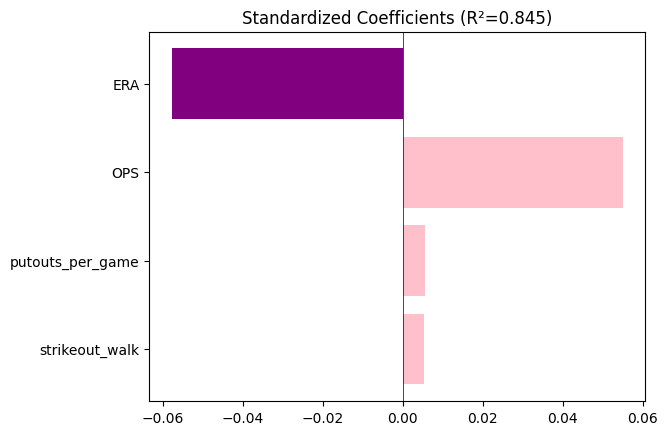

In [104]:
plt.barh(ordered_labels[::-1], ordered_values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Standardized Coefficients (R²=0.845)')
plt.show()

In [105]:
predicted = model.predict(X_main)
X_main.columns

Index(['const', 'ERA', 'strikeout_walk', 'OPS', 'putouts_per_game'], dtype='object')

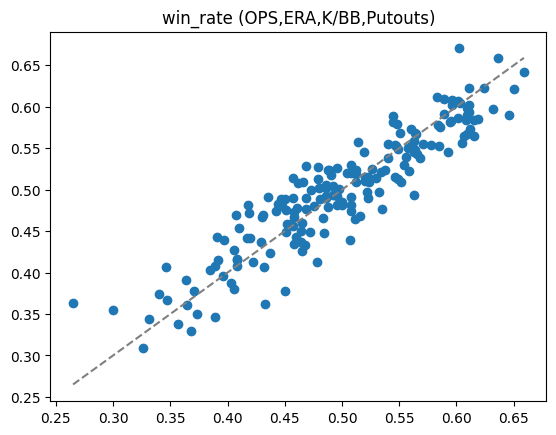

In [106]:
plt.scatter(all['win_rate'], predicted)

min_val = all['win_rate'].min()
max_val = all['win_rate'].max()

plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')
plt.title('win_rate (OPS,ERA,K/BB,Putouts)')

plt.show()

### 3-2. DIPS Theory - FIP-ERA Gap

Year specific FIP constants were derived from league averages (`league_year`), and the gap between FIP and ERA was calculated for each team-season. A positive gap (FIP > ERA) means actual runs allowed were lower than what the pitcher's skill alone would predict (suggesting defensive help). A negative gap suggests the defense failed to support the pitcher adequately, or the team was unlucky. **Better team defense tends to produce an actual ERA that outperforms FIP** (the defense-independent stat).

The largest gap belonged to the 2014 NC Dinos (+0.791) and the smallest to the 2013 Kia Tigers (-0.788). Comparing these against putouts_per_game showed almost no difference between the two extreme cases (26.6 vs. 26.8). This is likely because putouts_per_game is largely fixed by game rules and also includes strikeouts, a pitching, not defensive, skill. BABIP proved more suitable: larger gaps corresponded to lower BABIP and smaller gaps to higher BABIP (r=-0.48, stronger than putouts_per_game's r=0.40).

> BABIP was calculated as `(hits allowed - home runs) / (batters faced - strikeouts - home runs - walks - hit by pitch)`. Using a plate-appearance (PA) denominator makes the sacrifice-fly (SF) correction from the standard at-bat (AB) based formula unnecessary, since it cancels out algebraically. Sacrifice hits weren't excluded: the batting dataset's `sacrifice_hits` column tracks the team's own batters, not the opposing batters our pitchers faced, so it wasn't usable here. Given how rarely they occur, the effect is probably small.



In [107]:
fip_input = all[['home_runs','walks','hit_batter','pitcher_strikeouts','innings_pitched']]

In [108]:
fip_cols = (13*fip_input['home_runs'] + 3*(fip_input['walks']+fip_input['hit_batter']) - 2*fip_input['pitcher_strikeouts'] ) /fip_input['innings_pitched']

In [109]:
league_year= all.groupby('year').agg(
    earned_sum = ('earned_runs', 'sum'),
    innings_sum = ('innings_pitched', 'sum'),
    homerun_sum = ('home_runs', 'sum'),
    ball_sum = ('walks','sum'),
    hbp = ('hit_batter','sum'),
    k_sum = ('pitcher_strikeouts', 'sum')
)   
league_year['league_era'] = league_year['earned_sum'] / league_year['innings_sum'] * 9

In [110]:
league_year['league_raw_fip'] = (13*league_year['homerun_sum'] + 3*(league_year['ball_sum']+league_year['hbp']) - 2*league_year['k_sum']) / league_year['innings_sum']

In [111]:
league_year['fip_constant'] = league_year['league_era'] - league_year['league_raw_fip']
league_year['fip_constant']

year
2001    3.046292
2002    2.944942
2003    2.718445
2004    2.899892
2005    2.971211
2006    2.658075
2007    2.768198
2008    3.108601
2009    3.135129
2010    3.235300
2011    3.150783
2012    3.060057
2013    3.349352
2014    3.771226
2015    3.552025
2016    3.741097
2017    3.677110
2018    3.771390
2019    3.354048
2020    3.498213
2021    3.281274
Name: fip_constant, dtype: float64

In [112]:
league_year[['league_era','league_raw_fip','fip_constant']]

,league_era,league_raw_fip,fip_constant
year,,,
2001,4.707839,1.661547,3.046292
2002,4.237717,1.292775,2.944942
2003,4.269767,1.551322,2.718445
2004,4.292779,1.392887,2.899892
2005,4.214992,1.243781,2.971211
2006,3.584374,0.926299,2.658075
2007,3.908788,1.140590,2.768198
2008,4.114736,1.006135,3.108601
2009,4.797015,1.661885,3.135129


In [113]:
all['fip_constant']=all.year.map(league_year['fip_constant'])

In [114]:
all.fip_constant

0      3.281274
1      3.281274
2      3.281274
3      3.281274
4      3.281274
         ...   
179    3.046292
180    3.046292
181    3.046292
182    3.046292
183    3.046292
Name: fip_constant, Length: 184, dtype: float64

In [115]:
all[['year','fip_constant']].drop_duplicates().sort_values('year')

,year,fip_constant
176,2001,3.046292
168,2002,2.944942
160,2003,2.718445
152,2004,2.899892
144,2005,2.971211
136,2006,2.658075
128,2007,2.768198
120,2008,3.108601
112,2009,3.135129
104,2010,3.235300


In [116]:
all['FIP'] = fip_cols + all['fip_constant']
all['fip_era_gap'] = all['FIP'] - all['ERA']
all.fip_era_gap.sort_values(ascending=False)

70     0.791127
120    0.688775
145    0.630692
128    0.614143
112    0.573951
         ...   
86    -0.622296
9     -0.651516
103   -0.661344
59    -0.720145
87    -0.788248
Name: fip_era_gap, Length: 184, dtype: float64

In [117]:
all[['team','year','ERA','FIP','fip_era_gap','putouts_per_game']].sort_values('fip_era_gap',ascending=False)

,team,year,ERA,FIP,fip_era_gap,putouts_per_game
70,NC Dinos,2014,4.29,5.081127,0.791127,26.617188
120,Incheon,2008,3.22,3.908775,0.688775,27.404762
145,Incheon,2005,3.41,4.040692,0.630692,27.071429
128,Incheon,2007,3.24,3.854143,0.614143,27.126984
112,Incheon,2009,3.67,4.243951,0.573951,27.360902
...,...,...,...,...,...,...
86,Hanwha Eagles,2013,5.31,4.687704,-0.622296,26.460938
9,Lotte Giants,2021,5.39,4.738484,-0.651516,26.479167
103,Hanwha Eagles,2011,5.11,4.448656,-0.661344,26.503759
59,KT Wiz,2016,5.92,5.199855,-0.720145,26.520833


In [118]:
babip = all['batters_faced'] - all['pitcher_strikeouts'] - all['home_runs'] - all['walks'] - all['hit_batter']
all['BABIP'] = (all['hits_allowed']-all['home_runs']) / babip
all['BABIP']

0      0.285479
1      0.292558
2      0.311907
3      0.308061
4      0.302804
         ...   
179    0.301058
180    0.287440
181    0.298515
182    0.304059
183    0.309949
Name: BABIP, Length: 184, dtype: float64

In [119]:
all[['team','year','ERA','FIP','fip_era_gap','putouts_per_game','BABIP']].sort_values('fip_era_gap',ascending=False)

,team,year,ERA,FIP,fip_era_gap,putouts_per_game,BABIP
70,NC Dinos,2014,4.29,5.081127,0.791127,26.617188,0.303387
120,Incheon,2008,3.22,3.908775,0.688775,27.404762,0.280737
145,Incheon,2005,3.41,4.040692,0.630692,27.071429,0.268852
128,Incheon,2007,3.24,3.854143,0.614143,27.126984,0.277332
112,Incheon,2009,3.67,4.243951,0.573951,27.360902,0.291522
...,...,...,...,...,...,...,...
86,Hanwha Eagles,2013,5.31,4.687704,-0.622296,26.460938,0.311117
9,Lotte Giants,2021,5.39,4.738484,-0.651516,26.479167,0.314932
103,Hanwha Eagles,2011,5.11,4.448656,-0.661344,26.503759,0.314993
59,KT Wiz,2016,5.92,5.199855,-0.720145,26.520833,0.350860


In [120]:
all[['fip_era_gap','BABIP']].corr()

,fip_era_gap,BABIP
fip_era_gap,1.000000,-0.480665
BABIP,-0.480665,1.000000


In [121]:
all[['fip_era_gap','putouts_per_game']].corr()

,fip_era_gap,putouts_per_game
fip_era_gap,1.000000,0.396124
putouts_per_game,0.396124,1.000000


### 3-3. Pythagorean Residual Analysis

Pythagorean expected win rate (`runs scored² / (runs scored² + runs allowed²)`) was calculated and compared against actual win rate to compute residuals. Residuals varied widely within the same team across seasons, indicating they reflect season-specific factors rather than fixed team strength. The team with the highest average residual was Hanwha Eagles, a franchise with a reputation as historically weak, meaning it outperformed expectations even within an otherwise poor run differential.

Residuals showed a weak positive correlation with saves (r=0.29), suggesting bullpen stability as a possible partial factor, though save opportunities vary by team, so this remains tentative. Residuals showed no meaningful correlation with the FIP-ERA gap (r=-0.15), suggesting they relate more to factors like bullpen usage than to pitcher skill itself.

In [122]:
all['predicted_winrate'] = (all['runs_scored']**2) / ((all['runs_scored']**2)+(all['runs_allowed']**2))

In [123]:
all['residual']=all['win_rate']-all['predicted_winrate']
all['residual'].sort_values(ascending=False)

103    0.070957
8      0.066841
78     0.062484
32     0.056467
17     0.053639
         ...   
70    -0.044037
81    -0.044361
22    -0.049289
119   -0.053796
179   -0.077541
Name: residual, Length: 184, dtype: float64

In [124]:
all.groupby('team')['residual'].mean().sort_values(ascending=False)

team
Hanwha Eagles       0.013835
Hyundai Unicorns    0.008485
Kia Tigers          0.007673
Samsung Lions       0.005375
LG Twins           -0.003121
Incheon            -0.003476
Doosan Bears       -0.006749
KT Wiz             -0.006928
Heroes             -0.009031
Lotte Giants       -0.011359
NC Dinos           -0.012406
Name: residual, dtype: float64

In [125]:
all[['team','year','residual']].sort_values('residual',ascending=False)

,team,year,residual
103,Hanwha Eagles,2011,0.070957
8,Kia Tigers,2021,0.066841
78,Hanwha Eagles,2014,0.062484
32,Hanwha Eagles,2018,0.056467
17,Kia Tigers,2020,0.053639
...,...,...,...
70,NC Dinos,2014,-0.044037
81,NC Dinos,2013,-0.044361
22,Heroes,2019,-0.049289
119,Hanwha Eagles,2009,-0.053796


In [126]:
all[['team', 'year', 'win_rate', 'predicted_winrate', 'residual']].sort_values('residual',ascending=False).head()

,team,year,win_rate,predicted_winrate,residual
103,Hanwha Eagles,2011,0.450,0.379043,0.070957
8,Kia Tigers,2021,0.433,0.366159,0.066841
78,Hanwha Eagles,2014,0.389,0.326516,0.062484
32,Hanwha Eagles,2018,0.535,0.478533,0.056467
17,Kia Tigers,2020,0.507,0.453361,0.053639


In [127]:
all[['team', 'year', 'win_rate', 'predicted_winrate', 'residual']].sort_values('residual',ascending=False).tail()

,team,year,win_rate,predicted_winrate,residual
70,NC Dinos,2014,0.551,0.595037,-0.044037
81,NC Dinos,2013,0.419,0.463361,-0.044361
22,Heroes,2019,0.601,0.650289,-0.049289
119,Hanwha Eagles,2009,0.346,0.399796,-0.053796
179,Lotte Giants,2001,0.457,0.534541,-0.077541


In [128]:
all[['residual','saves']].corr()

,residual,saves
residual,1.000000,0.290297
saves,0.290297,1.000000


In [129]:
all[['residual','fip_era_gap']].corr()

,residual,fip_era_gap
residual,1.000000,-0.148272
fip_era_gap,-0.148272,1.000000


### 3-4. Scoring Power vs Run Prevention

Batting (OPS) was used as the scoring power index. Pitching and defense (the z-score average of ERA, K/BB, and putouts_per_game, with ERA sign-reversed) formed the run prevention index. A two-variable regression was run on win_rate. These two indices alone reached R²=0.726, retaining most of the explanatory power of the four-variable model (0.845). Both coefficients were strongly significant (p<0.001). 

A naive comparison of the raw coefficients (run prevention 0.0749 vs. scoring power 0.0340) suggested run prevention was roughly 2.2x stronger. But averaging multiple z-scores compresses the standard deviation below 1 (to roughly 0.7 here). Correcting for this by multiplying each coefficient by its variable's actual standard deviation gives a fair "effect per one standard deviation" comparison: run prevention (0.0538) vs. scoring power (0.0340), (`run_prevent_effect / scoring_effect` = 1.58103). The direction held after correction, though the gap narrowed from the naive estimate: **run prevention is roughly 1.58x stronger** than scoring power in explaining win rate.

In [130]:
colz_1= ((all['ERA']-all['ERA'].mean())/all['ERA'].std())*(-1)


In [131]:
limit_allowed = (colz_1 + colz_2 + colz_4)/3

In [132]:
scoring_index = colz_3

In [133]:
X = pd.DataFrame({'run_prevent' : limit_allowed, 'scoring': scoring_index})
y = all['win_rate']

In [134]:
X=sm.add_constant(X)
model4=sm.OLS(y,X).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:               win_rate   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     239.8
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           1.31e-51
Time:                        22:13:10   Log-Likelihood:                 326.89
No. Observations:                 184   AIC:                            -647.8
Df Residuals:                     181   BIC:                            -638.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.4992      0.003    164.028      

In [135]:
X.describe()

,const,run_prevent,scoring
count,184.0,1.840000e+02,1.840000e+02
mean,1.0,2.703152e-15,9.267949e-16
std,0.0,7.176913e-01,1.000000e+00
min,1.0,-1.707368e+00,-2.001122e+00
25%,1.0,-5.486970e-01,-7.676346e-01
50%,1.0,6.351408e-02,2.681494e-02
75%,1.0,5.248467e-01,7.428649e-01
max,1.0,1.683672e+00,2.870108e+00


In [136]:
run_prevent_effect = 0.0749 * X['run_prevent'].std()
scoring_effect = 0.0340 * X['scoring'].std()

In [137]:
print(run_prevent_effect)
print(scoring_effect)

0.05375507624139887
0.034


In [138]:
print(run_prevent_effect/scoring_effect)

1.5810316541587903


## 4. Limitations & Future Work

**Data Limitations**
- Save data is a raw count, and save opportunities vary by team, making it a poor standalone measure of bullpen quality; the absence of game-level logs prevented calculating more precise metrics like close-game win rate
- Pitching/batting data only extends through 2021, excluding the 2022–2024 seasons
- wOBA was excluded due to the absence of KBO-specific linear weights; OPS was used as the composite batting metric instead

**Methodological Limitations**
- The weak correlation between putouts_per_game and ERA (-0.47) means their respective contributions to win rate may not be fully separated in the regression coefficients and could partially overlap (shared variance)
- The FIP constant was derived from year-by-year league averages rather than an official KBO coefficient, so it is safer to interpret year-over-year trends rather than absolute values
- BABIP could not exclude sacrifice hits from the denominator, since the batting dataset's `sacrifice_hits` column reflects the team's own batters rather than the opposing batters the pitching staff faced (a minor deviation from the strict definition, likely with minimal impact).

**Unexplained Variance**
- The weak correlation between Pythagorean residuals and saves (r=0.29) suggests some of team performance depends on factors this analysis couldn't capture — close-game luck, injury timing, short-term variance.

**Future Work**
- Split regression by win-rate tier (bottom/middle/top): deferred this round due to sample size constraints, but as more data accumulates, this could reveal whether what it takes to escape last place differs from what it takes to compete for a championship.
- Extend the analysis through the 2022–2024 seasons once pitching/batting data becomes available
- With game-level (game log) data, re-examine residual drivers using more precise metrics such as one-run game win rate and actual save conversion rate
